# analysis.cooccurrence-habitat

In this notebook, we aim to understand:
- how cooccurrences are distributed across sites
- how cooccurrences could be related with site species richness

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from daforfer import DaforferDB
import matplotlib.pyplot as plt
import networkx as nx
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
from miripvir25.statistics import mann_whitney_posthoc
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

┌─────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  name   │                                                        description                                                        │
│ varchar │                                                          varchar                                                          │
├─────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1 │ Table S1: Library sites and context                                                                                       │
│ TableS2 │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3 │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4 │ Habitat-level diversity and number o

## Load data

In [2]:
alpha_diversity = db.conn.sql('SELECT * FROM D_Site_level_div').df()
alpha_diversity

,site,habitat,disturbed,species_richness_bact,species_richness_vir,species_richness_plant,species_richness_host,coccurrence_codetections,cooccurrence_detections
0,C1,Crop,disturbed,6,18,12,4,5.0,5.0
1,C2,Crop,disturbed,8,12,17,5,1.0,1.0
2,H1,Crop,disturbed,1,13,9,3,0.0,0.0
3,H2,Crop,disturbed,1,12,9,3,1.0,1.0
4,H3,Crop,disturbed,4,33,12,4,4.0,4.0
5,M1,Crop,disturbed,2,20,14,5,3.0,1.0
6,M2,Crop,disturbed,1,13,9,4,2.0,1.0
7,M3,Crop,disturbed,2,9,11,4,0.0,0.0
8,M4,Crop,disturbed,1,9,16,3,1.0,1.0
9,Z1,Crop,disturbed,11,14,13,6,10.0,9.0


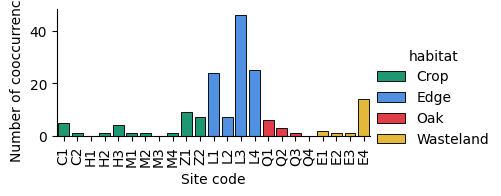

In [3]:
g = sns.catplot(alpha_diversity, x='site', y='cooccurrence_detections', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Number of cooccurrences")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.cooccurrencesbysite.colbyhabitat.svg")

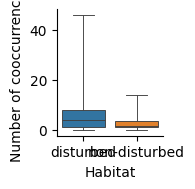

In [4]:
g = sns.catplot(alpha_diversity, x='disturbed', y='cooccurrence_detections', height=2.0, aspect=1.0, hue='disturbed', linewidth=0.65, kind='box', whis=1000)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Number of cooccurrences")
g.set_xlabels("Habitat")
# g.set_xticklabels(rotation=90)
g.savefig("figures/boxplot.cooccurrences.bydisturbance.svg")

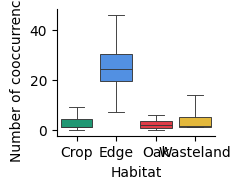

In [5]:
g = sns.catplot(alpha_diversity, x='habitat', y='cooccurrence_detections', height=2.0, aspect=1.25, hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=1000)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Number of cooccurrences")
g.set_xlabels("Habitat")
# g.set_xticklabels(rotation=90)
g.savefig("figures/boxplot.cooccurrences.byhabitat.svg")

In [6]:
KW = stats.kruskal(
    alpha_diversity.query('habitat == "Crop"')['cooccurrence_detections'],
    alpha_diversity.query('habitat == "Edge"')['cooccurrence_detections'],
    alpha_diversity.query('habitat == "Oak"')['cooccurrence_detections'],
    alpha_diversity.query('habitat == "Wasteland"')['cooccurrence_detections'],
)

# db.add_value('KW_H_cooccurrences_by_habitat', 'Kruskal-Wallis test on cooccurrences by habitat, H-value', KW.statistic, 'FLOAT')
# db.add_value('KW_p_cooccurrences_by_habitat', 'Kruskal-Wallis test on cooccurrences by habitat, p-value', KW.pvalue, 'FLOAT')
KW

KruskalResult(statistic=np.float64(8.974935400516802), pvalue=np.float64(0.02962599690430585))

In [7]:
MW = stats.mannwhitneyu(
    alpha_diversity.query('habitat == "Crop" or habitat == "Edge"')['cooccurrence_detections'],
    alpha_diversity.query('habitat == "Oak" or habitat == "Wasteland"')['cooccurrence_detections']
)
# db.add_value('MW_H_cooccurrences_by_dist', 'Mann-Whitney-U test on cooccurrences by habitat, U-value', MW.statistic, 'FLOAT')
# db.add_value('MW_p_cooccurrences_by_dist', 'Mann-Whitney-U test on cooccurrences by habitat, p-value', MW.pvalue, 'FLOAT')
MW 

MannwhitneyuResult(statistic=np.float64(70.5), pvalue=np.float64(0.5091414608966655))

### Post-hoc analysis

In [8]:
post_hoc_stats = mann_whitney_posthoc(alpha_diversity, 'habitat', 'cooccurrence_detections')
post_hoc_stats

,group_1,group_2,U,p-val,sign
0,Crop,Edge,42.5,0.007721,True
1,Crop,Oak,22.5,1.000000,False
2,Crop,Wasteland,27.0,0.535319,False
3,Edge,Crop,42.5,0.007721,True
4,Edge,Oak,16.0,0.028571,True
5,Edge,Wasteland,15.0,0.059072,False
6,Oak,Crop,22.5,1.000000,False
7,Oak,Edge,16.0,0.028571,True
8,Oak,Wasteland,9.0,0.882420,False
9,Wasteland,Crop,27.0,0.535319,False


In [9]:


db.save_dataframe(
    df=post_hoc_stats, table_name="T_coocByHabitat",
    description="Post-Hoc Mann Whitney U analysis on number of cooccurrennt pairs by habitat, group1 < group2"
)

si.save_dataframe(
    df=post_hoc_stats, table_name="TableS6",
    description="Mann-Whitney U post-hoc test on site-diversity by habitat"
)

post_hoc_stats

Saved T_coocByHabitat to db.2025-11-17
Saved TableS6 to si.2025-11-17


,group_1,group_2,U,p-val,sign
0,Crop,Edge,42.5,0.007721,True
1,Crop,Oak,22.5,1.000000,False
2,Crop,Wasteland,27.0,0.535319,False
3,Edge,Crop,42.5,0.007721,True
4,Edge,Oak,16.0,0.028571,True
5,Edge,Wasteland,15.0,0.059072,False
6,Oak,Crop,22.5,1.000000,False
7,Oak,Edge,16.0,0.028571,True
8,Oak,Wasteland,9.0,0.882420,False
9,Wasteland,Crop,27.0,0.535319,False


In [10]:
post_hoc_stats.pivot(index='group_1', columns='group_2', values='p-val').round(4)

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,0.0077,1.0000,0.5353
Edge,0.0077,NaN,0.0286,0.0591
Oak,1.0000,0.0286,NaN,0.8824
Wasteland,0.5353,0.0591,0.8824,NaN


In [11]:
post_hoc_stats.pivot(index='group_1', columns='group_2', values='U').round(4)

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,42.5,22.5,27.0
Edge,42.5,NaN,16.0,15.0
Oak,22.5,16.0,NaN,9.0
Wasteland,27.0,15.0,9.0,NaN


## Correlation between site-alpha-diversity and site-number of cooccurrences

In [12]:
# alpha_diversity = pd.read_csv("output/diversity.all.csv", sep=";")
# alpha_diversity = db.conn.sql('SELECT * FROM D_ADAllOrganismsSite').df().drop(columns=['disturbed'])
# alpha_diversity = pd.merge(alpha_diversity, site_cooccurrences, on=['site', 'habitat'])
# db.save_dataframe(
#     alpha_diversity, table_name="Alpha_diversity_bysite_cooccurrences",
#     description="Alpha diveristy and cooccurrences by site"
# )
# alpha_diversity

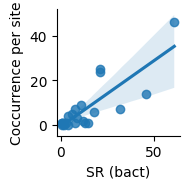

In [13]:
g = sns.lmplot(alpha_diversity, x='species_richness_bact', y='cooccurrence_detections', height=2.0)
g.set_xlabels("SR (bact)")
g.set_ylabels("Coccurrence per site")

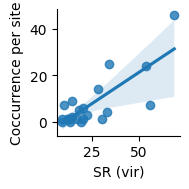

In [14]:
g = sns.lmplot(alpha_diversity, x='species_richness_vir', y='cooccurrence_detections', height=2.0)
g.set_xlabels("SR (vir)")
g.set_ylabels("Coccurrence per site")

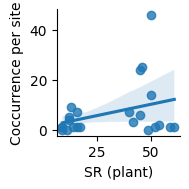

In [15]:
g = sns.lmplot(alpha_diversity, x='species_richness_plant', y='cooccurrence_detections', height=2.0)
g.set_xlabels("SR (plant)")
g.set_ylabels("Coccurrence per site")

In [16]:
def reg2dict(x, level):

    return {"level": level, "p-value": x.pvalue, "r-value": x.rvalue, "slope": x.slope}
regression_tests = pd.DataFrame.from_records([
    reg2dict(stats.linregress(alpha_diversity['species_richness_bact'], alpha_diversity['cooccurrence_detections']), "Bact"),
    reg2dict(stats.linregress(alpha_diversity['species_richness_vir'], alpha_diversity['cooccurrence_detections']), "Virus"),
    reg2dict(stats.linregress(alpha_diversity['species_richness_plant'], alpha_diversity['cooccurrence_detections']), "Plant")
])

db.save_dataframe(
    regression_tests, table_name='T_coocDivBySite',
    description='Correlation tests between species richness and number of coocurrences detected at each site'
)
regression_tests.set_index('level').T.round(4)[['Virus', 'Bact', 'Plant']]

Saved T_coocDivBySite to db.2025-11-17


level,Virus,Bact,Plant
p-value,0.0000,0.0000,0.1391
r-value,0.7887,0.8165,0.3181
slope,0.5350,0.5909,0.1802


In [17]:
db.conn.close()
si.conn.close()